In [7]:
%matplotlib inline


In [8]:
!pip install -q \
  "transformers==4.46.2" \
  "accelerate==0.34.2" \
  "sentencepiece" \
  "datasets==2.20.0" \
  "pandas==2.2.2" \
  "pyarrow<20"


In [9]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
import pandas as pd
import numpy as np

print("torch:", torch.__version__)

from huggingface_hub import login, whoami, hf_hub_download
from getpass import getpass

HF_TOKEN = getpass("Paste your Hugging Face token: ").strip()
login(HF_TOKEN, add_to_git_credential=False)
print("Logged in as:", whoami().get("name", "unknown"))

try:
    cfg_path = hf_hub_download(
        "meta-llama/Llama-3.2-1B-Instruct", "config.json", token=HF_TOKEN
    )
    print("Able to access Llama config at:", cfg_path)
except Exception as e:
    print("Warning: Llama access check failed:", e)


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

torch: 2.8.0+cu126
Paste your Hugging Face token: ··········


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Logged in as: prakasi
Able to access Llama config at: /root/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/snapshots/9213176726f574b556790deb65791e0c5aa438b6/config.json


In [10]:
import torch
import math
from typing import List, Tuple, Dict, Any

def load_model(model_id: str, hf_token: str = None):

    dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

    tok = AutoTokenizer.from_pretrained(model_id, use_fast=True, token=hf_token)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        token=hf_token,
        torch_dtype=dtype,
        device_map="auto",
    )
    model.eval()
    return tok, model

def token_entropies_from_logits_list(scores: List[torch.Tensor]) -> Tuple[List[float], float]:

    H = []
    for step_logits in scores:
        probs = torch.softmax(step_logits[0], dim=-1)
        ent = -torch.sum(probs * torch.log(probs + 1e-12)).item()
        H.append(ent)
    return H, (float(np.mean(H)) if H else float("nan"))

def build_prompt_for_model(raw_prompt: str, family: str) -> Dict[str, Any]:

    if family in {"llama", "deepseek"}:
        system = "You are a strict coding assistant. Output only valid Python code for the function, no explanations."
        user = raw_prompt + "\n\n# Your code below:\n"
        messages = [
            {"role": "system", "content": system},
            {"role": "user", "content": user},
        ]
        return {"chat": True, "messages": messages}

    if family == "qwen-coder":
        text = raw_prompt + "\n# Your code below:\n"
        return {"chat": False, "text": text}

    return {"chat": False, "text": raw_prompt + "\n# Your code below:\n"}

@torch.inference_mode()
@torch.inference_mode()


@torch.inference_mode()


def generate_with_entropy(tok, model, raw_prompt: str, family: str,
                          max_new_tokens: int = 320,
                          temperature: float = 0.0,
                          top_p: float = 1.0) -> Dict[str, Any]:
    """
    Deterministic generation + per-step logits -> mean token entropy.
    - Uses chat template if available (LLaMA instruct, DeepSeek instruct, etc.).
    - Falls back to plain text prompt if no chat_template (e.g., DeepSeek base, generic models).
    """
    device = model.device
    spec = build_prompt_for_model(raw_prompt, family)

    has_chat_template = getattr(tok, "chat_template", None) not in (None, "")

    if spec["chat"] and has_chat_template:
        input_ids = tok.apply_chat_template(
            spec["messages"], add_generation_prompt=True, return_tensors="pt"
        ).to(device)
        attention_mask = None
    else:
        if spec["chat"]:
            parts = []
            for msg in spec["messages"]:
                role = msg["role"]
                content = msg["content"]
                if role == "system":
                    parts.append(f"[SYSTEM] {content}\n")
                elif role == "user":
                    parts.append(f"[USER] {content}\n")
                else:
                    parts.append(f"[{role.upper()}] {content}\n")
            text = "".join(parts) + "\n[ASSISTANT]\n"
        else:
            text = spec["text"]

        enc = tok(text, return_tensors="pt")
        input_ids = enc["input_ids"].to(device)
        attention_mask = enc.get("attention_mask", None)
        if attention_mask is not None:
            attention_mask = attention_mask.to(device)

    gen_kwargs = dict(
        input_ids=input_ids,
        max_new_tokens=max_new_tokens,
        do_sample=False if temperature == 0.0 else True,
        temperature=temperature,
        top_p=top_p,
        return_dict_in_generate=True,
        output_scores=True,
        pad_token_id=tok.eos_token_id,
    )
    if attention_mask is not None:
        gen_kwargs["attention_mask"] = attention_mask

    out = model.generate(**gen_kwargs)

    gen_ids = out.sequences[0, input_ids.shape[1]:]
    gen_text = tok.decode(gen_ids, skip_special_tokens=True)

    H_list, H_mean = token_entropies_from_logits_list(out.scores)

    return {
        "generated_code": gen_text,
        "mean_token_entropy_nats": H_mean,
        "first5_entropies": H_list[:5],
        "num_steps": len(H_list),
        "num_chars": len(gen_text),
    }


In [16]:
heval = load_dataset("openai_humaneval")["test"]
N_SAMPLES = 5
subset = [heval[i] for i in range(len(heval))]
print(f"Using {len(subset)} HumanEval tasks.")
print("Example task_id:", subset[0]["task_id"])


Using 164 HumanEval tasks.
Example task_id: HumanEval/0


In [12]:
MODELS = [
    # -------- DeepSeek Coder family (your updated set) --------
    ("deepseek", "≈1.3B-base",     "deepseek-ai/deepseek-coder-1.3b-base"),
    ("deepseek", "≈1.3B-instruct", "deepseek-ai/deepseek-coder-1.3b-instruct"),
    ("deepseek", "≈7B-instruct",   "deepseek-ai/deepseek-coder-7b-instruct-v1.5"),

    # -------- Qwen2.5-Coder family --------
    ("qwen-coder","≈1B", "Qwen/Qwen2.5-Coder-1.5B"),
    ("qwen-coder","≈3B", "Qwen/Qwen2.5-Coder-3B"),
    ("qwen-coder","≈8B", "Qwen/Qwen2.5-Coder-7B"),

    # -------- LLaMA 3 family --------
    ("llama",     "≈1B", "meta-llama/Llama-3.2-1B-Instruct"),
    ("llama",     "≈3B", "meta-llama/Llama-3.2-3B-Instruct"),
    ("llama",     "≈8B", "meta-llama/Meta-Llama-3-8B-Instruct"),
]


In [18]:
import gc, time

rows = []

for family, size_bucket, model_id in MODELS:
    print(f"\nLoading model: {model_id}  [{family} / {size_bucket}]")
    try:
        t0 = time.time()
        tok, model = load_model(model_id, hf_token=HF_TOKEN)
        print(f"Loaded in {time.time() - t0:.1f}s")
    except RuntimeError as e:
        print(f"Failed to load {model_id}: {e}")
        continue

    for item in subset:
        task_id = item["task_id"]
        prompt  = item["prompt"]
        try:
            res = generate_with_entropy(
                tok, model, prompt, family=family,
                max_new_tokens=320, temperature=0.0, top_p=1.0
            )
        except RuntimeError as e:
            if "CUDA out of memory" in str(e):
                print(f"OOM while generating for {model_id} / {task_id}. Skipping this model.")
                res = None
                break
            else:
                raise

        if res is None:
            break

        rows.append({
            "family": family,
            "size_bucket": size_bucket,
            "model_id": model_id,
            "task_id": task_id,
            "mean_token_entropy_nats": res["mean_token_entropy_nats"],
            "first5_entropies": res["first5_entropies"],
            "num_steps": res["num_steps"],
            "num_chars": res["num_chars"],
            "preview": (res["generated_code"][:180].replace("\n"," \\n ") +
                        ("..." if len(res["generated_code"])>180 else "")),
        })

    # free memory
    del model; del tok
    torch.cuda.empty_cache(); gc.collect()

df = pd.DataFrame(rows)
print(f"\nCollected {len(df)} rows.")
df.head(3)



Loading model: deepseek-ai/deepseek-coder-1.3b-base  [deepseek / ≈1.3B-base]
Loaded in 2.4s

Loading model: deepseek-ai/deepseek-coder-1.3b-instruct  [deepseek / ≈1.3B-instruct]
Loaded in 2.1s

Loading model: deepseek-ai/deepseek-coder-7b-instruct-v1.5  [deepseek / ≈7B-instruct]


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded in 6.4s

Loading model: Qwen/Qwen2.5-Coder-1.5B  [qwen-coder / ≈1B]
Loaded in 2.6s

Loading model: Qwen/Qwen2.5-Coder-3B  [qwen-coder / ≈3B]


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded in 3.8s

Loading model: Qwen/Qwen2.5-Coder-7B  [qwen-coder / ≈8B]


...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded in 4.1s

Loading model: meta-llama/Meta-Llama-3-8B-Instruct  [llama / ≈8B]


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loaded in 8.0s

Collected 1476 rows.


,family,size_bucket,model_id,task_id,mean_token_entropy_nats,first5_entropies,num_steps,num_chars,preview
0,deepseek,≈1.3B-base,deepseek-ai/deepseek-coder-1.3b-base,HumanEval/0,0.204942,"[3.176894187927246, 2.8660669326782227, 2.5594...",320,1008,\n \n [SYSTEM] You are a strict coding assis...
1,deepseek,≈1.3B-base,deepseek-ai/deepseek-coder-1.3b-base,HumanEval/1,0.169749,"[3.3341948986053467, 2.822932243347168, 2.6277...",320,1225,\n \n [SYSTEM] You are a strict coding assis...
2,deepseek,≈1.3B-base,deepseek-ai/deepseek-coder-1.3b-base,HumanEval/2,0.242526,"[2.3598852157592773, 2.9067604541778564, 2.361...",320,1087,\n def truncate_number(number: float) -> floa...


In [19]:
summary = (
    df.groupby(["family","size_bucket","model_id"])["mean_token_entropy_nats"]
      .agg(["count","mean","std"])
      .reset_index()
      .sort_values(["family","size_bucket"])
)
summary
df.to_csv("humaneval_entropy_allsamples_raw_no_quant.csv", index=False)
summary.to_csv("humaneval_entropy_allsamples_summary_no_quant.csv", index=False)
print("Saved CSVs.")

Saved CSVs.


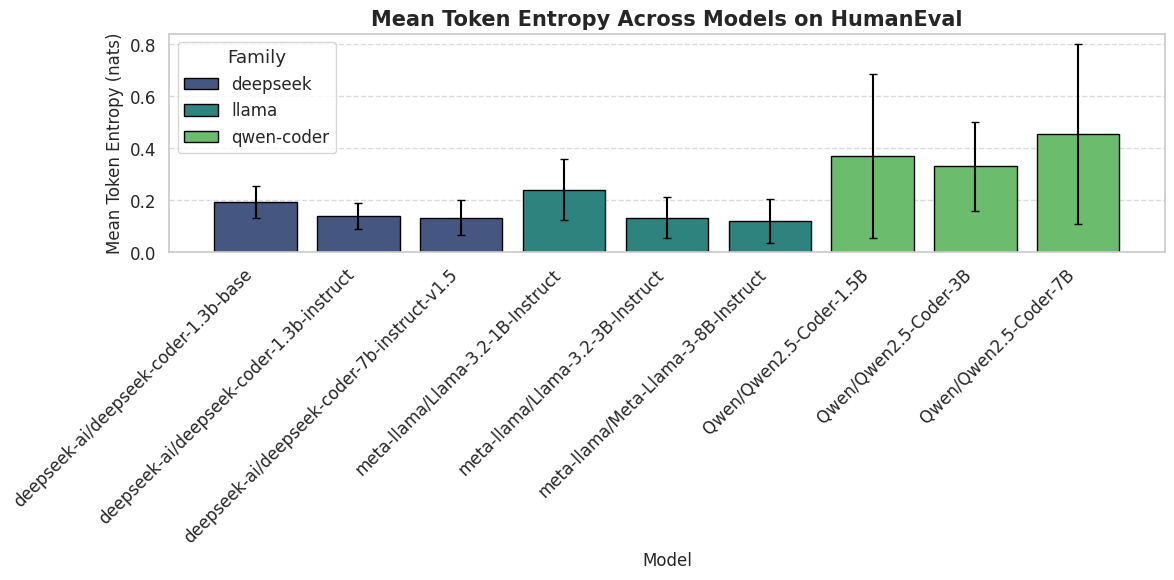

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_mean_token_entropy(csv_path: str, save_path: str = None, show_plot: bool = True):
    """
    Reads the saved entropy CSV and plots mean token entropy per model,
    grouped by family and size bucket.
    """

    df = pd.read_csv(csv_path)

    summary = (
        df.groupby(["family", "size_bucket", "model_id"])["mean_token_entropy_nats"]
          .agg(["mean", "std", "count"])
          .reset_index()
          .sort_values(["family", "size_bucket"])
    )

    sns.set(style="whitegrid", font_scale=1.1)
    plt.figure(figsize=(12, 6))

    ax = sns.barplot(
        data=summary,
        x="model_id",
        y="mean",
        hue="family",
        palette="viridis",
        dodge=False,
        edgecolor="black"
    )

    for i, row in summary.iterrows():
        ax.errorbar(
            i, row["mean"], yerr=row["std"], fmt="none", color="black", capsize=3
        )

    plt.title("Mean Token Entropy Across Models on HumanEval", fontsize=15, weight='bold')
    plt.xlabel("Model", fontsize=12)
    plt.ylabel("Mean Token Entropy (nats)", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title="Family")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"✅ Plot saved to {save_path}")

    if show_plot:
        plt.show()

plot_mean_token_entropy("humaneval_entropy_allsamples_raw_no_quant.csv")
